In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user just says "Hello". We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 72, 'total_tokens': 108, 'completion_time': 0.075454682, 'prompt_time': 0.00300571, 'queue_time': 0.05468159, 'total_time': 0.078460392, 'completion_tokens_details': {'reasoning_tokens': 18}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b4fa9-1ccb-71f0-8c1a-e08f9599182c-0', usage_metadata={'input_tokens': 72, 'output_tokens': 36, 'total_tokens': 108, 'output_token_details': {'reasoning': 18}})

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq


In [3]:
### create a state 

class LLMState(TypedDict):
    
    question: str
    answer: str
    


In [4]:
def llm_qa(state: LLMState) -> LLMState:
    
    # extract the question from the state
    question = state['question']
    
    ## form a prompt
    prompt = f'Answer the following question concisely: {question}'
    
    ## asl that question of the LLM 
    answer = llm.invoke(prompt).content
    
    ## update the answer to the LLM 
    answer = llm.invoke(prompt).content
    
    state['answer'] = answer
    
    return state

In [5]:
## create oour graph
graph = StateGraph(LLMState)

## add nodes
graph.add_node("llm_qa", llm_qa)

## add edges
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

## compile the graph
graph_workflow = graph.compile()


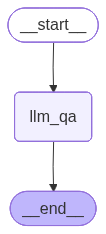

In [6]:
from IPython.display import Image
Image(graph_workflow.get_graph().draw_mermaid_png())

In [8]:
## execute the workflow
initial_state = LLMState(question="What is the capital of France?")
final_state = graph_workflow.invoke(initial_state)

final_state

{'question': 'What is the capital of France?', 'answer': 'Paris.'}

In [9]:
print(final_state['answer'])

Paris.
